# LemoScan AI | InceptionV3 transfer learning

**Six-class disease classifier. Manifest-based train/validation development only.**

We train a compact classifier on ImageNet features, then fine-tune the final Inception block at a much lower learning rate. Validation loss controls stopping and checkpoint selection across both phases. The test set is reserved for a separate, one-time evaluation after development is frozen.

No source image, split assignment, ResNet checkpoint, or application code is modified. No package is installed automatically. The final metadata references InceptionV3 and is compatible with the existing metadata loader; no frontend integration work is performed here.

**Known data limitation:** 410 unresolved Category C/D candidate pairs cross the manifest split. They were not proven same-source and were not automatically merged. Validation performance therefore does not establish complete biological independence or field reliability.


## 1. Environment, feasibility, and reproducibility
Run all cells in a fresh kernel. Seeds are fixed at 42, TensorFlow deterministic operations are requested, and environment/device details are saved. Exact replay can still depend on hardware and library versions. A synthetic gradient check verifies TensorFlow execution before training. Missing required libraries stop execution without installation.


In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import platform
import shutil
import time

required = ["tensorflow", "keras", "numpy", "pandas", "PIL", "matplotlib", "sklearn", "IPython"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing: raise ImportError(f"Missing required dependencies: {missing}. No installation attempted.")
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from PIL import Image, ImageOps
from IPython.display import display, Markdown
from tensorflow.keras.applications.inception_v3 import preprocess_input

SEED = 42
PROJECT_ROOT_OVERRIDE = None
ALLOW_RETRAIN_OVERWRITE = False  # Set explicitly only to replace this notebook's Inception artifacts.
IMG_SIZE = (299, 299)
PHASE1_EPOCHS = 25
FINETUNE_EPOCHS = 15
PHASE1_LR = 1e-3
FINETUNE_LR = 1e-5
DROPOUT_RATE = 0.40
L2_STRENGTH = 1e-4
CLASSES = sorted(["Algal leaf spot", "Black spot", "Citrus canker", "Citrus pest", "Greening", "Healthy leaf"])
EXPECTED_COUNTS = {"train": 1435, "val": 308, "test": 307}
try:
    tf.config.threading.set_intra_op_parallelism_threads(4)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    print("TensorFlow threads already configured by this kernel; retaining existing settings.")
physical_gpus = tf.config.list_physical_devices("GPU")
for gpu in physical_gpus:
    try: tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError: pass
DEVICE = "GPU" if physical_gpus else "CPU"
BATCH_SIZE = 24 if physical_gpus else 16
MAP_PARALLELISM = 2
PREFETCH_BATCHES = 2
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
probe = tf.Variable([[1.0, 2.0]])
with tf.GradientTape() as tape:
    probe_loss = tf.reduce_sum(probe * probe)
assert np.isfinite(tape.gradient(probe_loss, probe).numpy()).all()
del probe
ENVIRONMENT = {"python": platform.python_version(), "tensorflow": tf.__version__, "keras": keras.__version__,
               "numpy": np.__version__, "pandas": pd.__version__, "sklearn": sklearn.__version__,
               "device": DEVICE, "physical_devices": [device.name for device in tf.config.list_physical_devices()],
               "seed": SEED, "deterministic_ops_requested": True, "cpu_threads_intra": tf.config.threading.get_intra_op_parallelism_threads(),
               "cpu_threads_inter": tf.config.threading.get_inter_op_parallelism_threads()}
display(pd.Series(ENVIRONMENT, name="environment").to_frame())
print(f"Training device: {DEVICE}; batch size: {BATCH_SIZE}", flush=True)
RUN_STARTED = time.perf_counter()


Training device: CPU; batch size: 16


,environment
python,3.13.2
tensorflow,2.21.0
keras,3.14.1
numpy,2.3.4
pandas,2.3.3
sklearn,1.7.2
device,CPU
physical_devices,[/physical_device:CPU:0]
seed,42
deterministic_ops_requested,True


## 2. Manifest validation and artifact paths
Verify all 2,050 rows, six classes, unique paths, file existence, exact split counts, and group independence. Existence checks on test paths do not decode test images. Only train and validation records feed any pipeline, augmentation preview, fit call, or prediction.

The original physical folder names are ignored for partition selection. Inception artifacts are separate from ResNet. To protect completed training, this notebook stops if its checkpoints already exist unless ALLOW_RETRAIN_OVERWRITE is explicitly enabled.


In [2]:
def resolve_root(override=None):
    roots = [Path(override).expanduser().resolve()] if override else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in roots:
        if (root / "reports/final_split/final_split_manifest.csv").is_file() and (root / "utils/model_loader.py").is_file(): return root
    raise FileNotFoundError("Set PROJECT_ROOT_OVERRIDE to the LemoScan-AI root.")


def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""): digest.update(chunk)
    return digest.hexdigest()


ROOT = resolve_root(PROJECT_ROOT_OVERRIDE)
MANIFEST_PATH = ROOT / "reports/final_split/final_split_manifest.csv"
REPORT_DIR = ROOT / "reports/inceptionv3_training"
MODEL_DIR = ROOT / "model"
TRAINING_DIR = ROOT / "training"
PHASE1_PATH = MODEL_DIR / "inceptionv3_phase1_best.keras"
PHASE2_PATH = MODEL_DIR / "inceptionv3_finetune_best.keras"
FINAL_PATH = MODEL_DIR / "inceptionv3_best_model.keras"
METADATA_PATH = MODEL_DIR / "model_metadata.json"
CLASS_PATH = TRAINING_DIR / "inceptionv3_class_indices.json"
existing = [str(path) for path in (PHASE1_PATH, PHASE2_PATH, FINAL_PATH, METADATA_PATH) if path.exists()]
if existing and not ALLOW_RETRAIN_OVERWRITE:
    raise FileExistsError(f"Existing Inception/metadata artifacts: {existing}. Review before setting ALLOW_RETRAIN_OVERWRITE=True.")
manifest = pd.read_csv(MANIFEST_PATH, keep_default_na=False)
assert len(manifest) == 2050 and manifest.filepath.is_unique
assert set(manifest["class"]) == set(CLASSES)
assert manifest.new_split.value_counts().to_dict() == EXPECTED_COUNTS
assert manifest.groupby("source_group_id").new_split.nunique().eq(1).all()
assert manifest.groupby("sha256").new_split.nunique().eq(1).all()
for relative in manifest.filepath:
    path = (ROOT / relative).resolve()
    assert path.is_relative_to((ROOT / "dataset").resolve()) and path.is_file(), relative
MANIFEST_HASH = file_sha256(MANIFEST_PATH)
# File stat snapshots, including test files, do not open/decode image content.
DATASET_STATS = {str(p): (p.stat().st_size, p.stat().st_mtime_ns) for p in (ROOT / "dataset").rglob("*") if p.is_file()}
PROTECTED = [ROOT / "model/resnet_best_model.keras", ROOT / "app.py", ROOT / "streamlit_app.py",
             ROOT / "utils/model_loader.py", ROOT / "utils/prediction.py", ROOT / "utils/xai.py",
             ROOT / "reports/dataset_audit/manual_review_decisions.csv"]
PROTECTED_HASHES = {str(p): file_sha256(p) for p in PROTECTED}
train_frame = manifest.loc[manifest.new_split.eq("train")].sort_values("filepath").reset_index(drop=True)
val_frame = manifest.loc[manifest.new_split.eq("val")].sort_values("filepath").reset_index(drop=True)
assert set(train_frame.filepath).isdisjoint(val_frame.filepath)
assert set(train_frame.filepath).isdisjoint(manifest.loc[manifest.new_split.eq("test"), "filepath"])
assert set(val_frame.filepath).isdisjoint(manifest.loc[manifest.new_split.eq("test"), "filepath"])
for directory in (REPORT_DIR, MODEL_DIR, TRAINING_DIR): directory.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / "environment.json").write_text(json.dumps(ENVIRONMENT, indent=2) + "\n", encoding="utf-8")
print("Manifest counts:", manifest.new_split.value_counts().to_dict())
print("Only train and val pipelines will be constructed; test pixels remain unread.")


Manifest counts: {'train': 1435, 'val': 308, 'test': 307}
Only train and val pipelines will be constructed; test pixels remain unread.


## 3. Deterministic six-class mapping
Alphabetical labels are persisted with the model. No negative/validator class is included.


In [3]:
class_indices = {name: index for index, name in enumerate(CLASSES)}
CLASS_PATH.write_text(json.dumps(class_indices, indent=2) + "\n", encoding="utf-8")
display(pd.DataFrame({"class": CLASSES, "index": range(len(CLASSES))}))


,class,index
0,Algal leaf spot,0
1,Black spot,1
2,Citrus canker,2
3,Citrus pest,3
4,Greening,4
5,Healthy leaf,5


## 4. Mild augmentation and manifest-based tf.data
Small rotations (up to roughly 18 degrees), horizontal flips, 8% zoom, 5% translation, and 10% contrast variation model modest framing/lighting changes. No vertical flips, severe crops, hue shifts, or aggressive distortions are introduced that could remove lesions.

Images decode as RGB, resize to 299 x 299, then augmentation (training only) precedes InceptionV3 preprocessing to [-1,1]. Validation stays deterministic and unaugmented. Modest parallelism/prefetch avoids CPU-memory oversubscription. No test dataset is constructed. No augmented-image cache freezes random transformations.


In [4]:
AUGMENTATION = {"horizontal_flip": True, "rotation_factor": 0.05, "zoom_factor": 0.08,
                "translation_height": 0.05, "translation_width": 0.05, "contrast_factor": 0.10,
                "fill_mode": "reflect"}


def make_augmentation(seed):
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=seed),
        tf.keras.layers.RandomRotation(0.05, fill_mode="reflect", seed=seed+1),
        tf.keras.layers.RandomZoom(0.08, fill_mode="reflect", seed=seed+2),
        tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode="reflect", seed=seed+3),
        tf.keras.layers.RandomContrast(0.10, seed=seed+4),
    ], name="leaf_augmentation")


augmentation = make_augmentation(SEED)


def decode_resize(path, label):
    raw = tf.io.read_file(path)
    image = tf.io.decode_image(raw, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(tf.cast(image, tf.float32), IMG_SIZE, method="bilinear")
    return image, label


def make_dataset(frame, training):
    expected = "train" if training else "val"
    assert frame.new_split.eq(expected).all(), "Only train/val data is permitted in this notebook."
    paths = [(ROOT / relative).as_posix() for relative in frame.filepath]
    labels = frame["class"].map(class_indices).to_numpy(dtype=np.int32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training: dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(decode_resize, num_parallel_calls=MAP_PARALLELISM, deterministic=True)
    dataset = dataset.batch(BATCH_SIZE)
    if training:
        dataset = dataset.map(lambda x, y: (preprocess_input(tf.clip_by_value(augmentation(x, training=True), 0., 255.)), y),
                              num_parallel_calls=1, deterministic=True)
    else:
        dataset = dataset.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=MAP_PARALLELISM, deterministic=True)
    options = tf.data.Options()
    options.experimental_deterministic = True
    options.threading.private_threadpool_size = 2
    return dataset.with_options(options).prefetch(PREFETCH_BATCHES)


train_ds = make_dataset(train_frame, training=True)
val_ds = make_dataset(val_frame, training=False)
print("Train batches:", int(tf.data.experimental.cardinality(train_ds)))
print("Validation batches:", int(tf.data.experimental.cardinality(val_ds)))


Cause: Unable to locate the source code of <function decode_resize at 0x00000213825FFEC0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: source code not available
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function make_dataset.<locals>.<lambda> at 0x00000213826D0040>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function make_dataset.<locals>.<lambda> at 0x00000213826D1E40>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_no

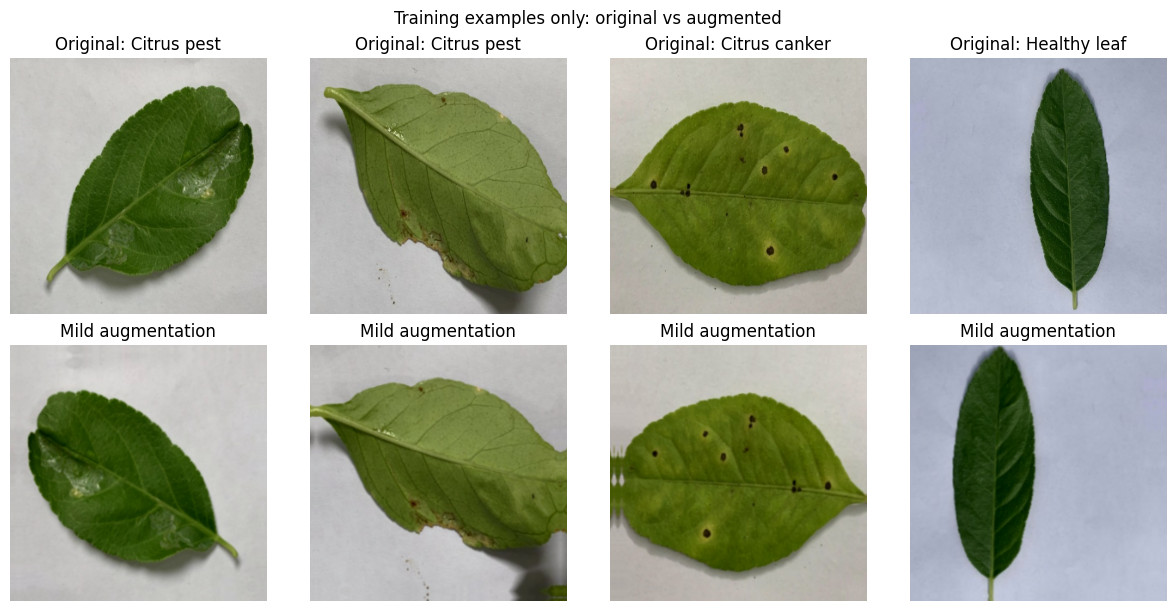

In [5]:
# Separate preview RNG leaves the training augmentation generator untouched.
preview_augmentation = make_augmentation(SEED + 100)
preview_rows = train_frame.sample(n=4, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(12, 6), layout="constrained")
for column, row in enumerate(preview_rows.to_dict("records")):
    original, _ = decode_resize(tf.constant((ROOT / row["filepath"]).as_posix()), tf.constant(0))
    augmented = tf.clip_by_value(preview_augmentation(original[None, ...], training=True)[0], 0, 255)
    axes[0, column].imshow(original.numpy().astype(np.uint8))
    axes[1, column].imshow(augmented.numpy().astype(np.uint8))
    axes[0, column].set_title(f"Original: {row['class']}")
    axes[1, column].set_title("Mild augmentation")
for ax in axes.ravel(): ax.axis("off")
fig.suptitle("Training examples only: original vs augmented")
fig.savefig(REPORT_DIR / "augmentation_examples.png", dpi=140, bbox_inches="tight")
plt.show()


## 5. Compact transfer-learning model
ImageNet InceptionV3 is frozen in Phase 1. The head is GlobalAveragePooling2D, 40% dropout, and six softmax outputs with mild L2 regularization. No extra dense stack or head BatchNormalization is added: the small CPU batch does not justify another set of moving statistics. The base is called with training=False, which also keeps pretrained BatchNormalization statistics fixed during fine-tuning.


In [6]:
base_model = tf.keras.applications.InceptionV3(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False
inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="preprocessed_rgb")
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(DROPOUT_RATE, name="dropout")(x)
outputs = tf.keras.layers.Dense(6, activation="softmax", kernel_regularizer=tf.keras.regularizers.l2(L2_STRENGTH), name="predictions")(x)
model = tf.keras.Model(inputs, outputs, name="inceptionv3_lemoscan_classifier")


def parameter_counts(model):
    trainable = int(sum(np.prod(weight.shape) for weight in model.trainable_weights))
    frozen = int(sum(np.prod(weight.shape) for weight in model.non_trainable_weights))
    return {"total": trainable + frozen, "trainable": trainable, "frozen": frozen}


PHASE1_PARAMETERS = parameter_counts(model)
print("Phase 1 parameters:", PHASE1_PARAMETERS)
model.summary()


Phase 1 parameters: {'total': 21815078, 'trainable': 12294, 'frozen': 21802784}
Model: "inceptionv3_lemoscan_classifier"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessed_rgb (InputLayer)   │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├───────────────────────────────

## 6. Phase 1 - feature extraction
Adam starts at 1e-3. At most 25 epochs are allowed; validation-loss early stopping (patience 5) restores best weights. ReduceLROnPlateau lowers the learning rate by 0.3 after three plateau epochs. ModelCheckpoint and early stopping monitor the same quantity. CSV logs persist every epoch even if execution is interrupted. Test data is never involved.


In [7]:
class EpochTiming(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.durations = []
    def on_epoch_begin(self, epoch, logs=None): self.started = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None):
        self.durations.append(time.perf_counter() - self.started)
        print(f"Epoch {epoch+1} wall time: {self.durations[-1]:.1f}s", flush=True)


def make_callbacks(path, csv_path, patience, reduce_patience):
    timer = EpochTiming()
    return [
        tf.keras.callbacks.ModelCheckpoint(str(path), monitor="val_loss", mode="min", save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=patience, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.3, patience=reduce_patience, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.CSVLogger(str(csv_path), append=False),
        tf.keras.callbacks.TerminateOnNaN(), timer,
    ], timer


model.compile(optimizer=tf.keras.optimizers.Adam(PHASE1_LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
phase1_callbacks, phase1_timer = make_callbacks(PHASE1_PATH, REPORT_DIR / "phase1_history.csv", patience=5, reduce_patience=3)
phase1_started = time.perf_counter()
history1 = model.fit(train_ds, validation_data=val_ds, epochs=PHASE1_EPOCHS, callbacks=phase1_callbacks, verbose=2)
PHASE1_SECONDS = time.perf_counter() - phase1_started
phase1_history = pd.DataFrame(history1.history)
phase1_history.insert(0, "epoch", np.arange(1, len(phase1_history)+1))
phase1_history["epoch_seconds"] = phase1_timer.durations
phase1_history.to_csv(REPORT_DIR / "phase1_history.csv", index=False)
assert np.isfinite(phase1_history[["loss", "val_loss"]].to_numpy()).all()
phase1_best_row = phase1_history.loc[phase1_history.val_loss.idxmin()]
print("Phase 1 best validation-loss epoch:", int(phase1_best_row.epoch))
print(phase1_best_row.to_dict())


Epoch 1/25

Epoch 1: val_loss improved from None to 0.78999, saving model to E:\LemoScan-AI\model\inceptionv3_phase1_best.keras

Epoch 1: finished saving model to E:\LemoScan-AI\model\inceptionv3_phase1_best.keras
Epoch 1 wall time: 146.4s
90/90 - 146s - 2s/step - accuracy: 0.5707 - loss: 1.1529 - val_accuracy: 0.7305 - val_loss: 0.7900 - learning_rate: 0.0010
Epoch 2/25

Epoch 2: val_loss improved from 0.78999 to 0.62108, saving model to E:\LemoScan-AI\model\inceptionv3_phase1_best.keras

Epoch 2: finished saving model to E:\LemoScan-AI\model\inceptionv3_phase1_best.keras
Epoch 2 wall time: 172.2s
90/90 - 172s - 2s/step - accuracy: 0.7415 - loss: 0.7162 - val_accuracy: 0.8117 - val_loss: 0.6211 - learning_rate: 0.0010
Epoch 3/25

Epoch 3: val_loss improved from 0.62108 to 0.53398, saving model to E:\LemoScan-AI\model\inceptionv3_phase1_best.keras

Epoch 3: finished saving model to E:\LemoScan-AI\model\inceptionv3_phase1_best.keras
Epoch 3 wall time: 153.0s
90/90 - 153s - 2s/step - acc

## 7. Phase-1 curves and overfitting diagnosis
The signed accuracy gap is training minus validation accuracy. Training includes augmentation and dropout while validation does not, so this gap is not a like-for-like generalization estimate. We report loss deterioration after the best epoch alongside training loss changes; neither one noisy epoch nor a negative gap proves the absence of overfitting.


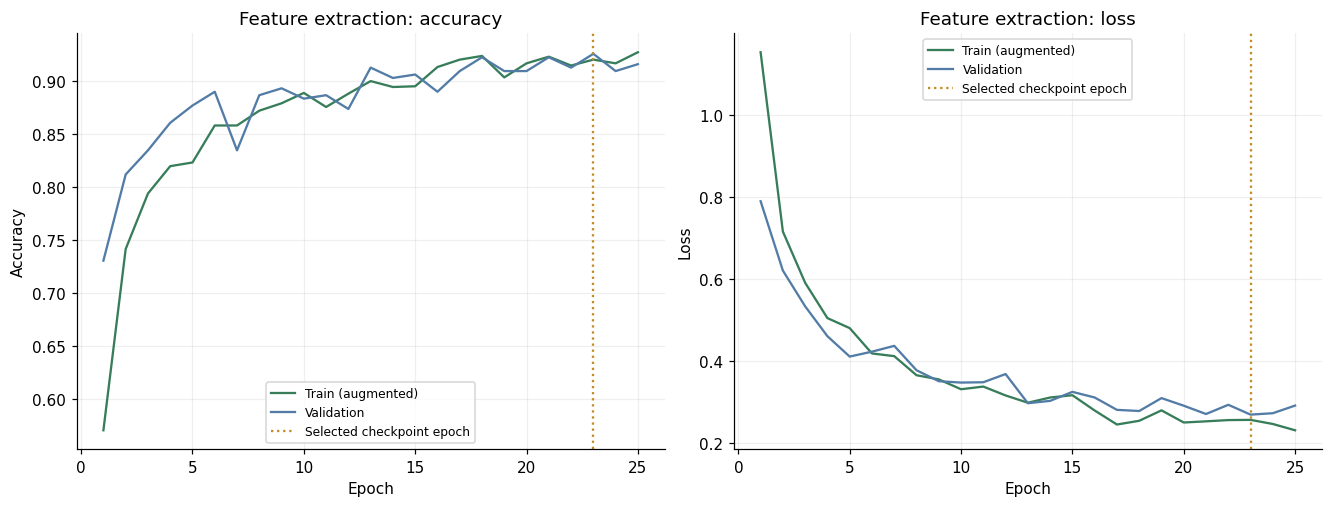

,phase1
best_epoch,23
best_validation_loss,0.270182
validation_accuracy_at_best_loss,0.925325
peak_validation_accuracy,0.925325
training_accuracy_at_best_loss,0.919861
train_minus_val_accuracy_gap_at_best_loss,-0.005464
epochs_after_best_with_val_loss_rise_over_0_01_and_lower_train_loss,1
overfitting_signal,False
interpretation,A sustained warning signal is >=2 later epochs...


In [8]:
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})


def plot_history(frame, title, output, boundary=None, best_epoch=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(frame.epoch, frame[metric], label="Train (augmented)", color="#377d59")
        ax.plot(frame.epoch, frame[f"val_{metric}"], label="Validation", color="#527ca6")
        if boundary is not None: ax.axvline(boundary, color="#555555", linestyle="--", label="Fine-tuning boundary")
        if best_epoch is not None: ax.axvline(best_epoch, color="#c38c26", linestyle=":", label="Selected checkpoint epoch")
        ax.set(xlabel="Epoch", ylabel=metric.capitalize(), title=f"{title}: {metric}")
        ax.grid(alpha=0.2); ax.legend(fontsize=8)
    fig.savefig(output, dpi=150, bbox_inches="tight"); plt.show()


def diagnose_history(frame):
    best_index = int(frame.val_loss.idxmin())
    best = frame.loc[best_index]
    later = frame.loc[frame.index > best_index]
    signal_count = int(((later.val_loss > best.val_loss + 0.01) & (later.loss < best.loss)).sum())
    return {"best_epoch": int(best.epoch), "best_validation_loss": float(best.val_loss),
            "validation_accuracy_at_best_loss": float(best.val_accuracy),
            "peak_validation_accuracy": float(frame.val_accuracy.max()),
            "training_accuracy_at_best_loss": float(best.accuracy),
            "train_minus_val_accuracy_gap_at_best_loss": float(best.accuracy - best.val_accuracy),
            "epochs_after_best_with_val_loss_rise_over_0_01_and_lower_train_loss": signal_count,
            "overfitting_signal": signal_count >= 2,
            "interpretation": "A sustained warning signal is >=2 later epochs with val_loss > best+0.01 while training loss is lower. This is a descriptive heuristic, not a statistical test."}


phase1_diagnosis = diagnose_history(phase1_history)
plot_history(phase1_history, "Feature extraction", REPORT_DIR / "phase1_training_curves.png", best_epoch=int(phase1_best_row.epoch))
display(pd.Series(phase1_diagnosis, name="phase1").to_frame())


## 8. Phase 2 - controlled fine-tuning
Reload the best Phase-1 checkpoint. Unfreeze only layers after mixed9 (the final Inception block) and keep **every BatchNormalization layer frozen**. Calling the backbone with training=False preserves its moving statistics. Recompile with a new Adam optimizer at 1e-5. Validation-loss patience is 4; learning rate drops after two plateau epochs. Fresh callbacks avoid carrying Phase-1 callback state into Phase 2.

A separate fine-tuning checkpoint is retained. The final `inceptionv3_best_model.keras` will be the lower-validation-loss checkpoint across **both** phases, so fine-tuning cannot replace a better Phase-1 model with a worse one.


In [9]:
model = tf.keras.models.load_model(PHASE1_PATH, compile=False)
base_model = model.get_layer("inception_v3")
base_model.trainable = True
boundary_index = next(i for i, layer in enumerate(base_model.layers) if layer.name == "mixed9")
for index, layer in enumerate(base_model.layers):
    layer.trainable = index > boundary_index and not isinstance(layer, tf.keras.layers.BatchNormalization)
assert all(not layer.trainable for layer in base_model.layers if isinstance(layer, tf.keras.layers.BatchNormalization))
PHASE2_LAYER_COUNTS = {"backbone_layers": len(base_model.layers),
                       "frozen_backbone_layers": sum(not layer.trainable for layer in base_model.layers),
                       "unfrozen_backbone_layers": sum(layer.trainable for layer in base_model.layers),
                       "unfrozen_weighted_backbone_layers": sum(layer.trainable and bool(layer.weights) for layer in base_model.layers),
                       "frozen_batchnorm_layers": sum(isinstance(layer, tf.keras.layers.BatchNormalization) for layer in base_model.layers),
                       "unfreeze_after_layer": "mixed9", "boundary_index": boundary_index}
PHASE2_PARAMETERS = parameter_counts(model)
print("Fine-tuning layers:", PHASE2_LAYER_COUNTS)
print("Fine-tuning parameters:", PHASE2_PARAMETERS)
model.compile(optimizer=tf.keras.optimizers.Adam(FINETUNE_LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
phase2_callbacks, phase2_timer = make_callbacks(PHASE2_PATH, REPORT_DIR / "finetune_history.csv", patience=4, reduce_patience=2)
phase2_started = time.perf_counter()
history2 = model.fit(train_ds, validation_data=val_ds, epochs=FINETUNE_EPOCHS, callbacks=phase2_callbacks, verbose=2)
PHASE2_SECONDS = time.perf_counter() - phase2_started
phase2_history = pd.DataFrame(history2.history)
phase2_history.insert(0, "epoch", np.arange(1, len(phase2_history)+1))
phase2_history["epoch_seconds"] = phase2_timer.durations
phase2_history.to_csv(REPORT_DIR / "finetune_history.csv", index=False)
assert np.isfinite(phase2_history[["loss", "val_loss"]].to_numpy()).all()
phase2_best_row = phase2_history.loc[phase2_history.val_loss.idxmin()]
phase2_diagnosis = diagnose_history(phase2_history)
SELECTED_PHASE = "phase2" if phase2_best_row.val_loss < phase1_best_row.val_loss else "phase1"
selected_path = PHASE2_PATH if SELECTED_PHASE == "phase2" else PHASE1_PATH
selected_row = phase2_best_row if SELECTED_PHASE == "phase2" else phase1_best_row
shutil.copy2(selected_path, FINAL_PATH)
assert file_sha256(FINAL_PATH) == file_sha256(selected_path)
print("Final checkpoint selected strictly by minimum validation loss:", SELECTED_PHASE)
print("Final model:", FINAL_PATH)


Fine-tuning layers: {'backbone_layers': 311, 'frozen_backbone_layers': 289, 'unfrozen_backbone_layers': 22, 'unfrozen_weighted_backbone_layers': 9, 'frozen_batchnorm_layers': 94, 'unfreeze_after_layer': 'mixed9', 'boundary_index': 279}
Fine-tuning parameters: {'total': 21815078, 'trainable': 6082566, 'frozen': 15732512}
Epoch 1/15

Epoch 1: val_loss improved from None to 0.25963, saving model to E:\LemoScan-AI\model\inceptionv3_finetune_best.keras

Epoch 1: finished saving model to E:\LemoScan-AI\model\inceptionv3_finetune_best.keras
Epoch 1 wall time: 134.7s
90/90 - 135s - 1s/step - accuracy: 0.9206 - loss: 0.2323 - val_accuracy: 0.9286 - val_loss: 0.2596 - learning_rate: 1.0000e-05
Epoch 2/15

Epoch 2: val_loss improved from 0.25963 to 0.25221, saving model to E:\LemoScan-AI\model\inceptionv3_finetune_best.keras

Epoch 2: finished saving model to E:\LemoScan-AI\model\inceptionv3_finetune_best.keras
Epoch 2 wall time: 127.3s
90/90 - 127s - 1s/step - accuracy: 0.9401 - loss: 0.1979 - v

## 9. Combined curves and phase comparison
The boundary is marked between the final feature-extraction epoch and the first fine-tuning epoch. Best-loss accuracy and peak accuracy are reported separately: a peak-accuracy epoch does not override loss-based model selection.


Change in best validation loss (phase2 - phase1): -0.133507
These comparisons describe validation behavior only; independent generalization requires the reserved test evaluation.


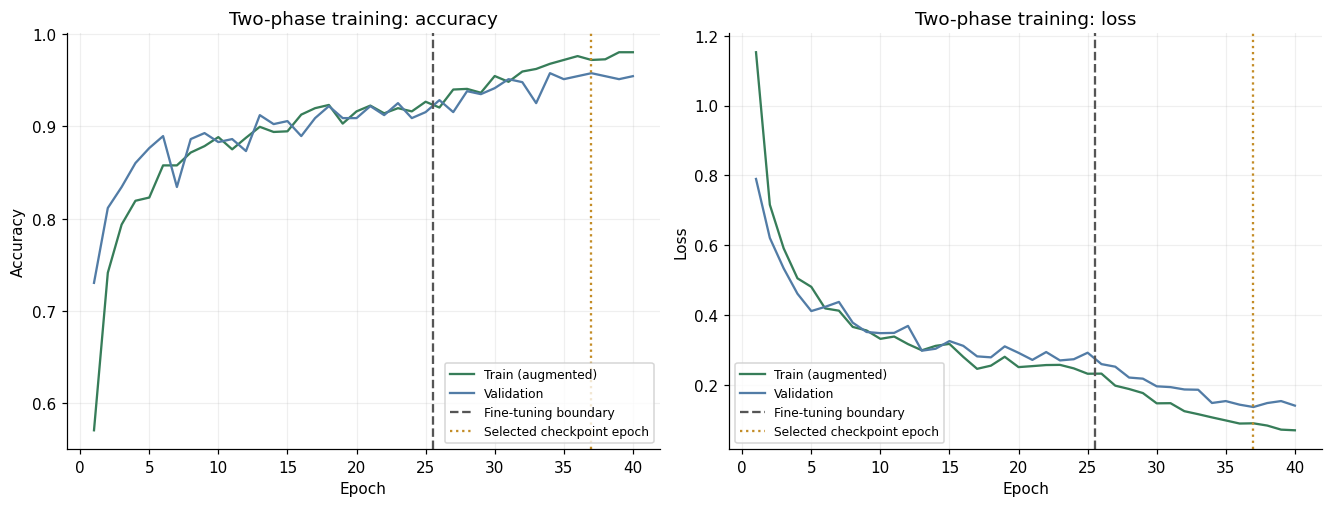

,best_epoch,best_validation_loss,validation_accuracy_at_best_loss,peak_validation_accuracy,training_accuracy_at_best_loss,train_minus_val_accuracy_gap_at_best_loss,epochs_after_best_with_val_loss_rise_over_0_01_and_lower_train_loss,overfitting_signal
phase1,23,0.270182,0.925325,0.925325,0.919861,-0.005464,1,False
phase2,12,0.136674,0.957792,0.957792,0.972125,0.014333,2,True


In [10]:
combined = pd.concat([phase1_history.assign(phase="phase1"), phase2_history.assign(phase="phase2", epoch=phase2_history.epoch + len(phase1_history))], ignore_index=True)
combined.to_csv(REPORT_DIR / "combined_history.csv", index=False)
selected_global_epoch = int(selected_row.epoch) + (len(phase1_history) if SELECTED_PHASE == "phase2" else 0)
plot_history(combined, "Two-phase training", REPORT_DIR / "combined_training_curves.png", boundary=len(phase1_history)+0.5, best_epoch=selected_global_epoch)
comparison = pd.DataFrame([phase1_diagnosis, phase2_diagnosis], index=["phase1", "phase2"])
display(comparison.drop(columns="interpretation"))
print(f"Change in best validation loss (phase2 - phase1): {phase2_best_row.val_loss - phase1_best_row.val_loss:+.6f}")
print("These comparisons describe validation behavior only; independent generalization requires the reserved test evaluation.")


## 10. Validation evaluation only
Reload the final selected checkpoint and evaluate the unshuffled validation pipeline. Report loss, accuracy, macro/weighted precision, recall, F1, and all six classes' metrics. This validation set has been used for development and is not an unbiased final test. No test pipeline, test predictions, or test metrics are created.


20/20 - 23s - 1s/step - accuracy: 0.9578 - loss: 0.1367


,validation_only
loss,0.136674
accuracy,0.957792
macro_precision,0.958988
macro_recall,0.959422
macro_f1,0.958629
weighted_precision,0.958749
weighted_recall,0.957792
weighted_f1,0.957686


,precision,recall,f1-score,support
Algal leaf spot,0.958333,1.000000,0.978723,46.000000
Black spot,0.903846,0.940000,0.921569,50.000000
Citrus canker,0.929825,0.963636,0.946429,55.000000
Citrus pest,0.982759,0.966102,0.974359,59.000000
Greening,0.979167,0.886792,0.930693,53.000000
Healthy leaf,1.000000,1.000000,1.000000,45.000000
accuracy,0.957792,0.957792,0.957792,0.957792
macro avg,0.958988,0.959422,0.958629,308.000000
weighted avg,0.958749,0.957792,0.957686,308.000000


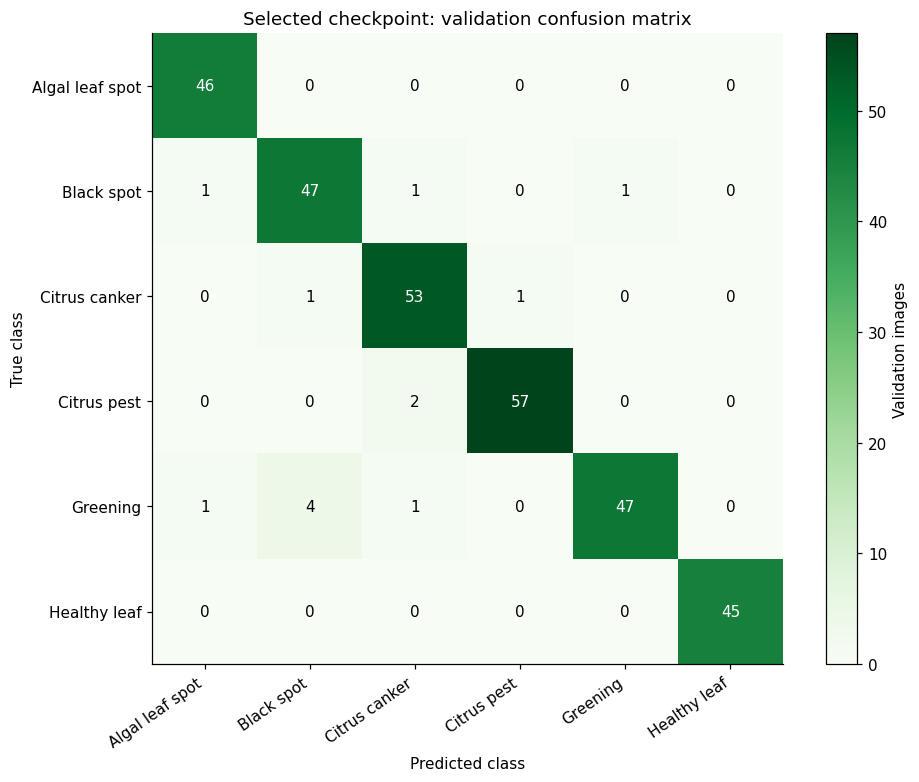

In [11]:
best_model = tf.keras.models.load_model(FINAL_PATH, compile=False)
best_model.compile(optimizer=tf.keras.optimizers.Adam(FINETUNE_LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
validation_evaluation = best_model.evaluate(val_ds, return_dict=True, verbose=2)
validation_probabilities = best_model.predict(val_ds, verbose=0)
y_true = val_frame["class"].map(class_indices).to_numpy(dtype=int)
y_pred = validation_probabilities.argmax(axis=1)
assert len(y_pred) == EXPECTED_COUNTS["val"] and validation_probabilities.shape == (308, 6)
assert np.isfinite(validation_probabilities).all()
report = classification_report(y_true, y_pred, labels=list(range(6)), target_names=CLASSES, output_dict=True, zero_division=0)
cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))
VALIDATION_METRICS = {"loss": float(validation_evaluation["loss"]), "accuracy": float(accuracy_score(y_true, y_pred))}
for average in ("macro", "weighted"):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=list(range(6)), average=average, zero_division=0)
    VALIDATION_METRICS.update({f"{average}_precision": float(precision), f"{average}_recall": float(recall), f"{average}_f1": float(f1)})
assert abs(VALIDATION_METRICS["accuracy"] - validation_evaluation["accuracy"]) < 1e-6
(REPORT_DIR / "validation_metrics.json").write_text(json.dumps(VALIDATION_METRICS, indent=2)+"\n", encoding="utf-8")
pd.DataFrame(report).transpose().to_csv(REPORT_DIR / "validation_classification_report.csv")
pd.DataFrame(cm, index=CLASSES, columns=CLASSES).to_csv(REPORT_DIR / "validation_confusion_matrix.csv")
validation_predictions = val_frame[["filepath", "class"]].rename(columns={"class": "true_class"}).copy()
validation_predictions["predicted_class"] = [CLASSES[index] for index in y_pred]
validation_predictions["confidence"] = validation_probabilities.max(axis=1)
validation_predictions.to_csv(REPORT_DIR / "validation_predictions.csv", index=False)
display(pd.Series(VALIDATION_METRICS, name="validation_only").to_frame())
display(pd.DataFrame(report).transpose())
fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
plot = ax.imshow(cm, cmap="Greens")
fig.colorbar(plot, ax=ax, label="Validation images")
for i in range(6):
    for j in range(6): ax.text(j, i, str(cm[i,j]), ha="center", va="center", color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set(xticks=np.arange(6), yticks=np.arange(6), xticklabels=CLASSES, yticklabels=CLASSES,
       xlabel="Predicted class", ylabel="True class", title="Selected checkpoint: validation confusion matrix")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.savefig(REPORT_DIR / "validation_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Validation error analysis
Inspect up to eight wrong validation predictions, ordered by confidence to make confident errors visible. This selection is descriptive, not a basis for another hyperparameter sweep in this run. Confidence is the softmax score, not calibrated certainty. No test images are shown.


Validation misclassifications: 13 / 308


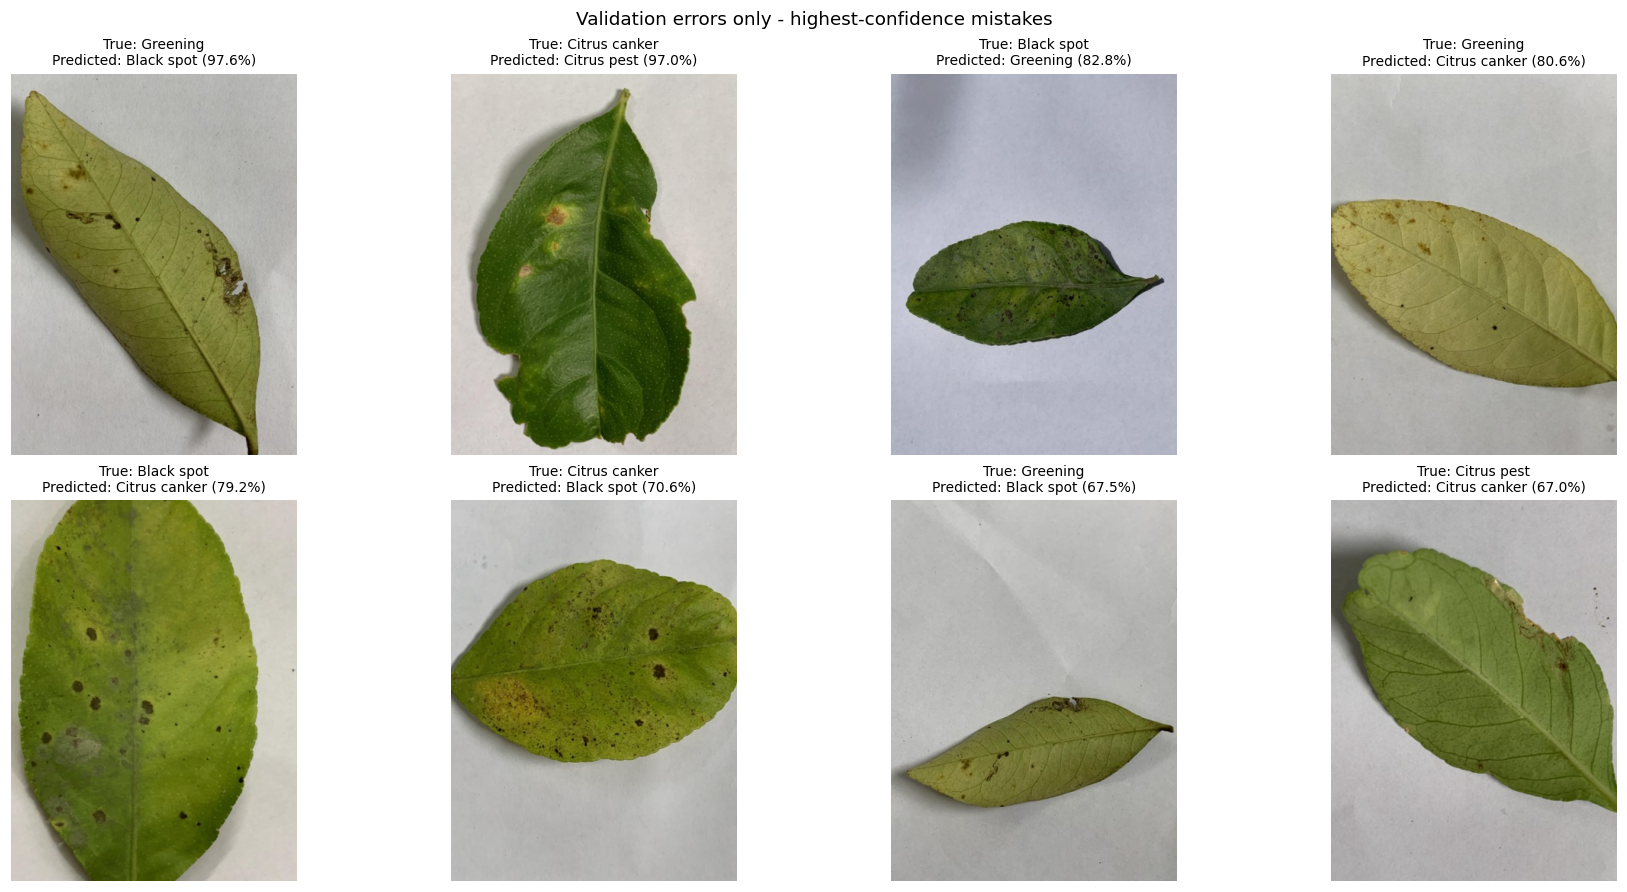

In [12]:
errors = validation_predictions.loc[validation_predictions.true_class.ne(validation_predictions.predicted_class)].sort_values(["confidence", "filepath"], ascending=[False, True])
print(f"Validation misclassifications: {len(errors)} / {len(val_frame)}")
shown_errors = errors.head(8)
if len(shown_errors):
    columns = min(4, len(shown_errors)); rows = int(np.ceil(len(shown_errors)/columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4*columns, 4*rows), squeeze=False, layout="constrained")
    for ax, row in zip(axes.ravel(), shown_errors.itertuples(index=False)):
        with Image.open(ROOT / row.filepath) as image:
            preview = ImageOps.exif_transpose(image).convert("RGB"); preview.thumbnail((500,500)); ax.imshow(preview)
        ax.set_title(f"True: {row.true_class}\nPredicted: {row.predicted_class} ({row.confidence:.1%})", fontsize=9)
    for ax in axes.ravel(): ax.axis("off")
    fig.suptitle("Validation errors only - highest-confidence mistakes")
else:
    fig, ax = plt.subplots(figsize=(7,2)); ax.axis("off"); ax.text(0.5,0.5,"No validation misclassifications",ha="center")
fig.savefig(REPORT_DIR / "validation_misclassifications.png", dpi=140, bbox_inches="tight")
plt.show()


## 12. Training summary and model metadata
Persist actual epochs, checkpoint criteria, phase timing, train/validation gaps, frozen/unfrozen layer counts, hyperparameters, and manifest/model hashes. The old ResNet model and application code remain unchanged. Metadata uses both the requested descriptive fields and the existing loader's architecture, image_size, and class_indices_path fields so preprocessing is unambiguous.


In [13]:
assert file_sha256(MANIFEST_PATH) == MANIFEST_HASH
assert PROTECTED_HASHES == {str(p): file_sha256(p) for p in PROTECTED}, "Protected model/app/decision file changed."
assert DATASET_STATS == {str(p): (p.stat().st_size, p.stat().st_mtime_ns) for p in (ROOT / "dataset").rglob("*") if p.is_file()}, "Dataset file membership/stat changed."
TRAINING_SECONDS = PHASE1_SECONDS + PHASE2_SECONDS
TOTAL_SECONDS = time.perf_counter() - RUN_STARTED
created_at = datetime.now(timezone.utc).isoformat()
relative = lambda path: path.relative_to(ROOT).as_posix()
summary = {"architecture": "InceptionV3", "image_size": list(IMG_SIZE), "channels": 3, "number_of_classes": 6,
           "batch_size": BATCH_SIZE, "seed": SEED, "augmentation": AUGMENTATION,
           "phase1_learning_rate": PHASE1_LR, "finetuning_learning_rate": FINETUNE_LR,
           "dropout_rate": DROPOUT_RATE, "head_l2": L2_STRENGTH,
           "phase1_epochs_run": len(phase1_history), "finetune_epochs_run": len(phase2_history),
           "phase1_max_epochs": PHASE1_EPOCHS, "finetune_max_epochs": FINETUNE_EPOCHS,
           "phase1_patience": 5, "finetune_patience": 4, "selection_metric": "minimum validation loss across both phases",
           "selected_phase": SELECTED_PHASE, "selected_phase_epoch": int(selected_row.epoch), "selected_global_epoch": selected_global_epoch,
           "phase1_best_epoch": int(phase1_best_row.epoch), "finetune_best_epoch": int(phase2_best_row.epoch),
           "peak_observed_validation_accuracy": float(combined.val_accuracy.max()),
           "validation_metrics": VALIDATION_METRICS,
           "selected_epoch_augmented_training_accuracy": float(selected_row.accuracy),
           "selected_epoch_train_minus_val_accuracy_gap": float(selected_row.accuracy-selected_row.val_accuracy),
           "phase1_diagnosis": phase1_diagnosis, "finetune_diagnosis": phase2_diagnosis,
           "overfitting_signal_observed": bool(phase1_diagnosis["overfitting_signal"] or phase2_diagnosis["overfitting_signal"]),
           "phase1_parameters": PHASE1_PARAMETERS, "finetune_parameters": PHASE2_PARAMETERS,
           "phase1_frozen_backbone_layers": PHASE2_LAYER_COUNTS["backbone_layers"],
           "phase1_unfrozen_backbone_layers": 0, "finetune_layer_counts": PHASE2_LAYER_COUNTS,
           "phase1_seconds": PHASE1_SECONDS, "finetune_seconds": PHASE2_SECONDS,
           "training_seconds": TRAINING_SECONDS, "total_notebook_seconds": TOTAL_SECONDS,
           "environment": ENVIRONMENT, "class_names": CLASSES, "class_indices": class_indices,
           "manifest_path": relative(MANIFEST_PATH), "manifest_sha256": MANIFEST_HASH,
           "final_model_path": relative(FINAL_PATH), "final_model_sha256": file_sha256(FINAL_PATH),
           "phase1_model_path": relative(PHASE1_PATH), "finetune_model_path": relative(PHASE2_PATH),
           "test_evaluated": False, "test_pipeline_constructed": False,
           "known_unresolved_CD_cross_split_pairs": 410,
           "limitation": "410 unresolved C/D similarity candidate pairs cross the split; they were not proven same-source and were not automatically merged. Validation was used for model development.",
           "timestamp_utc": created_at}
(REPORT_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2)+"\n", encoding="utf-8")
model_metadata = {"model_name": "InceptionV3", "architecture": "inceptionv3", "model_path": relative(FINAL_PATH),
                  "input_size": list(IMG_SIZE), "image_size": list(IMG_SIZE), "channels": 3, "number_of_classes": 6,
                  "class_names": CLASSES, "class_indices_path": relative(CLASS_PATH),
                  "preprocessing": "inception_v3.preprocess_input", "preprocessing_location": "external_before_model",
                  "training_manifest_path": relative(MANIFEST_PATH), "manifest_sha256": MANIFEST_HASH,
                  "random_seed": SEED, "validation_metrics": VALIDATION_METRICS,
                  "selection_metric": "validation_loss", "selected_phase": SELECTED_PHASE,
                  "test_evaluated": False, "timestamp_utc": created_at}
METADATA_PATH.write_text(json.dumps(model_metadata, indent=2)+"\n", encoding="utf-8")
print("Saved final model:", FINAL_PATH)
print("Training time, seconds:", round(TRAINING_SECONDS,1))
print("Full notebook time, seconds:", round(TOTAL_SECONDS,1))


Saved final model: E:\LemoScan-AI\model\inceptionv3_best_model.keras
Training time, seconds: 5322.2
Full notebook time, seconds: 5380.2


## 13. What we learned
The following conclusion is generated from this run. It distinguishes validation evidence from untouched-test generalization and reports the known dataset limitation rather than hiding it.


In [14]:
display(Markdown(f"""
**Phase 1:** {len(phase1_history)} epochs ran; best validation loss {phase1_best_row.val_loss:.5f} at epoch {int(phase1_best_row.epoch)}.

**Fine-tuning:** {len(phase2_history)} epochs ran with BatchNormalization frozen; best validation loss {phase2_best_row.val_loss:.5f} at epoch {int(phase2_best_row.epoch)}. Change from Phase 1: {phase2_best_row.val_loss-phase1_best_row.val_loss:+.5f}. The selected checkpoint is **{SELECTED_PHASE}**.

**Selected validation result:** accuracy {VALIDATION_METRICS['accuracy']:.2%}, loss {VALIDATION_METRICS['loss']:.5f}, macro F1 {VALIDATION_METRICS['macro_f1']:.4f}. Peak observed validation accuracy across epochs was {combined.val_accuracy.max():.2%}; selection used loss, not that peak.

**Overfitting evidence:** the documented sustained loss-divergence signal was {summary['overfitting_signal_observed']}. At the selected epoch, augmented training minus validation accuracy was {100*(selected_row.accuracy-selected_row.val_accuracy):+.2f} percentage points. Augmentation/dropout make these train/validation measurements different conditions; this gap alone does not prove absence or presence of overfitting.

**Next:** freeze development choices and perform the reserved test evaluation once in a separate notebook. No test predictions or performance metrics were computed here.

**Known limitation:** 410 unresolved Category C/D similarity candidate pairs cross the split. They were not considered proven same-source relationships and were not automatically merged. These results do not establish complete specimen independence.
"""))



**Phase 1:** 25 epochs ran; best validation loss 0.27018 at epoch 23.

**Fine-tuning:** 15 epochs ran with BatchNormalization frozen; best validation loss 0.13667 at epoch 12. Change from Phase 1: -0.13351. The selected checkpoint is **phase2**.

**Selected validation result:** accuracy 95.78%, loss 0.13667, macro F1 0.9586. Peak observed validation accuracy across epochs was 95.78%; selection used loss, not that peak.

**Overfitting evidence:** the documented sustained loss-divergence signal was True. At the selected epoch, augmented training minus validation accuracy was +1.43 percentage points. Augmentation/dropout make these train/validation measurements different conditions; this gap alone does not prove absence or presence of overfitting.

**Next:** freeze development choices and perform the reserved test evaluation once in a separate notebook. No test predictions or performance metrics were computed here.

**Known limitation:** 410 unresolved Category C/D similarity candidate pairs cross the split. They were not considered proven same-source relationships and were not automatically merged. These results do not establish complete specimen independence.
